# 07. 밑바닥부터 — CNN·RNN·역전파를 손으로 계산해 보기

노트북 01~06은 모델을 **만들고 돌리는** 법을 배웠다. 이 노트북은 방향을 바꾼다 —
**모델 안에서 실제로 어떤 숫자가 흐르는지**를 NumPy로 손계산하고,
그 결과가 Keras/TensorFlow와 **정확히 일치하는지** 대조한다.

핵심 관점 하나: **DNN·CNN·RNN은 완전히 다른 게 아니다.**
셋 다 결국 같은 연산 — `활성화(입력·가중치를 곱해서 다 더하기 + 편향)` — 을 쓴다.
차이는 딱 하나, **가중치를 어떻게 재사용하느냐**뿐이다.

| | 입력을 어떻게 보나 | 가중치를 어떻게 쓰나 |
|---|---|---|
| **DNN** | 전부 한 줄로 펼쳐서 한 번에 | 입력마다 전용 가중치 (재사용 X) |
| **CNN** | 2D 그대로, 작은 창으로 훑으며 | 작은 필터 하나를 위치마다 재사용 |
| **RNN** | 한 스텝씩 순서대로 | 같은 셀을 매 스텝 재사용 + 기억 전달 |

이 노트북의 세 파트:
1. **CNN** — 필터가 이미지를 훑어 특징 지도를 만드는 과정
2. **RNN** — 기억(state)이 스텝을 타고 흐르는 과정
3. **역전파** — 가중치가 "틀린 만큼" 조정되는 과정

## 1부. CNN — 필터가 "훑는다"는 게 실제로 뭔지

4×4 이미지(가운데 두 열에 세로선)에 3×3 "세로선 감지기" 필터를 대고,
**한 칸씩 옮기며** 곱해서 더한다. 그 결과가 **특징 지도(feature map)** 다.

```
잘린 3×3 조각      필터(가중치 9개)
0 1 1            -1  2 -1
0 1 1     ⊙      -1  2 -1   =  각 행 (0·-1 + 1·2 + 1·-1)=1,  세 행 → 3
0 1 1            -1  2 -1
```

**핵심 3가지:**
- 필터를 4곳에 대도 가중치 9개는 **항상 똑같다** → 이게 "재사용".
- 그래서 세로선이 **어디 있든** 이 필터 하나가 잡는다 (위치 불변).
- 필터의 `-1,2,-1`은 사람이 정하지 않는다. **학습으로 알아서 찾는다** (3부 참고).

아래 셀에서 NumPy 손계산 → MaxPooling → Keras Conv2D 대조 순으로 확인한다.
세 결과가 모두 `[[3,3],[3,3]]`으로 일치하면 원리 검증 성공.

In [18]:
import numpy as np

# 4x4 입력: 열 1,2에 세로선(값 1)이 있는 이미지
img = np.array([
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
    [0, 1, 1, 0],
], dtype=float)

# 3x3 "세로선 감지기" 필터: 가운데 열 +2, 양옆 -1
kernel = np.array([
    [-1, 2, -1],
    [-1, 2, -1],
    [-1, 2, -1],
], dtype=float)

# valid 합성곱: 3x3 필터를 4x4 위에서 2x2 = 4곳에 놓는다
out_h = img.shape[0] - kernel.shape[0] + 1 # 4-3+1 = 2
out_w = img.shape[1] - kernel.shape[1] + 1 # 2
feature_map = np.zeros((out_h, out_w))

for i in range(out_h):
  for j in range(out_w):
    patch = img[i:i+3, j:j+3] # 필터를 댈 3x3 조각
    feature_map[i, j] = np.sum(patch * kernel) # 곱해서 다 더함

print("입력 이미지:\n", img)
print("\n필터(세로선 감지기):\n", kernel)
print("\n특징 지도(feature map):\n", feature_map)
# 기대: [[3,3], [3,3]] - 세로선이 있는 곳마다 큰 값

입력 이미지:
 [[0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [0. 1. 1. 0.]
 [0. 1. 1. 0.]]

필터(세로선 감지기):
 [[-1.  2. -1.]
 [-1.  2. -1.]
 [-1.  2. -1.]]

특징 지도(feature map):
 [[3. 3.]
 [3. 3.]]


In [19]:
# 2x2 MaxPooling: 2x2 영역에서 최댓값 하나만
pooled = np.max(feature_map) # feature_map이 2x2라 결과는 스칼라 1개
print("MaxPooling 결과:", pooled) # 3.0 - "이 근처에 세로선 있다"만 남기고 위치는 버림

MaxPooling 결과: 3.0


In [20]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D

# (batch, H, W, channel) 형태로 변환
x = img.reshape(1, 4, 4, 1)

model = Sequential([
    Input(shape=(4,4,1)),
    Conv2D(filters=1, kernel_size=(3,3), padding='valid', use_bias=False),
])

# 학습 대신, 위에서 만든 세로선 필터를 강제로 넣어본다.
# Conv2D 가중치 shape: (kernel_h, kernel_w, in_channel, filters) = (3,3,1,1)
w = kernel.reshape(3,3,1,1)
model.set_weights([w])

result  = model.predict(x, verbose=0)
print("Keras Conv2D 결과:\n", result[0,:,:,0])
# NumPy 손계산(feature_map)과 똑같이 [[3,3],[3,3]]이 나오면 성공

Keras Conv2D 결과:
 [[3. 3.]
 [3. 3.]]


### 필터는 학습으로 만들어진다 — 실제로 확인

위에서는 필터를 손으로 `-1,2,-1`로 넣었다. 진짜 CNN은 이 값을 **역전파로 스스로 찾는다.**
이 노트북 안에서 작은 CNN을 MNIST로 **1에폭만** 학습시킨 뒤,
첫 Conv2D 층의 필터 32개를 꺼내 그림으로 본다.

아무도 "세로선 감지기를 만들어라"고 시키지 않았는데,
데이터가 필터를 특정 모양(선·곡선·질감 감지기)으로 밀어간 결과를 눈으로 확인하는 게 목적이다.
(03 노트북에 의존하지 않고 여기서 독립 실행한다.)

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.8751 - loss: 0.4633
필터 shape: (5, 5, 1, 32)


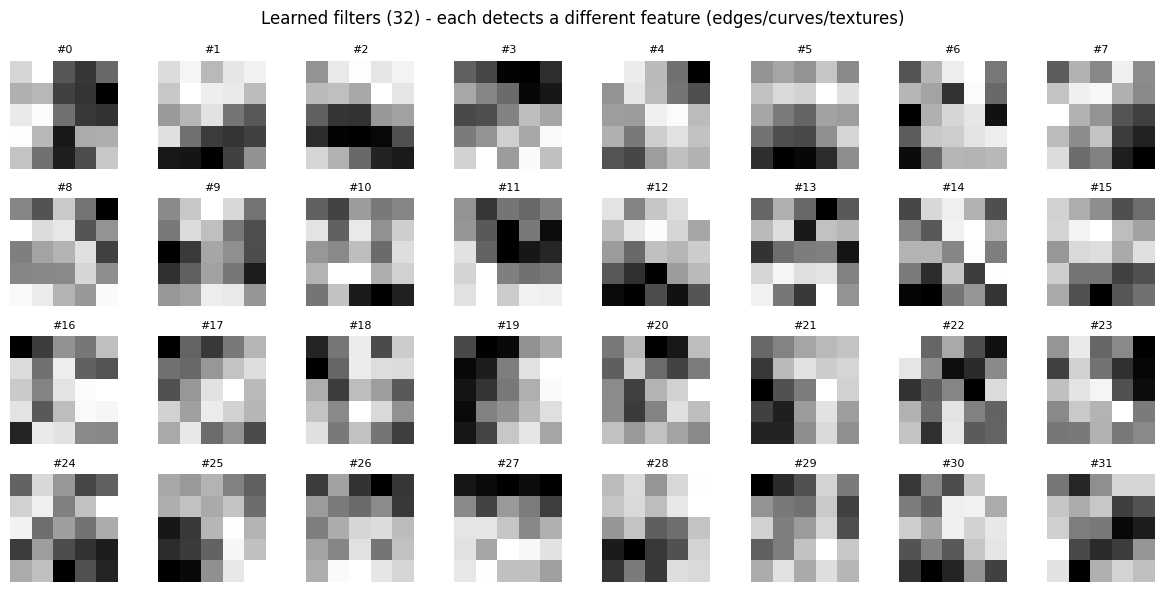

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical

# 이 노트북 안에서 자체적으로 작은 CNN을 잠깐 학습시켜 필터를 관찰한다.
# (03 노트북에 의존하지 않음 — scratch 노트북답게 독립 실행)
(x_tr, y_tr), _ = mnist.load_data()
x_tr = x_tr[:10000, :, :, np.newaxis] / 255.0   # 1만 장만, 빠르게
y_tr = to_categorical(y_tr[:10000])

cnn = Sequential([
    Input(shape=(28, 28, 1)),
    Conv2D(filters=32, kernel_size=(5, 5), padding='same', activation='relu'),  # 관찰 대상
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(10, activation='softmax'),
])
cnn.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
cnn.fit(x_tr, y_tr, epochs=1, verbose=1)   # 1에폭이면 필터가 형체를 갖추기에 충분

# 첫 Conv2D의 필터 32개 꺼내기
first_conv = cnn.layers[0]
weights = first_conv.get_weights()   # use_bias 기본 True → [filters, biases]
filters = weights[0]
print("필터 shape:", filters.shape)   # (5, 5, 1, 32)

# 32개 필터를 5×5 흑백 이미지로 나열
n = filters.shape[-1]
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for idx, ax in enumerate(axes.flat):
    if idx < n:
        ax.imshow(filters[:, :, 0, idx], cmap='gray')
        ax.set_title(f'#{idx}', fontsize=8)
    ax.axis('off')
plt.suptitle("Learned filters (32) - each detects a different feature (edges/curves/textures)")
plt.tight_layout()
plt.show()


## 2부. RNN — "기억(state)"이 실제로 뭔지

RNN 셀도 열어보면 가중합 두 개를 더한 것뿐이다:

```
새 기억 h_t = 활성화( 현재입력·Wx  +  직전기억 h_{t-1}·Wh  +  b )
                     └ 새로 들어온 것 ┘   └── 이전까지 본 것 ──┘
```

기억(h)은 그냥 **숫자(벡터)** 다. 매 스텝 "이번 입력"과 "직전 기억"을 함께 받아
새 기억을 만들고 다음 스텝으로 넘긴다. **Wx, Wh는 매 스텝 재사용**된다.

입력 `[2, 0, 0]`을 넣으면 (첫 스텝만 2):
```
h_1 = 2·Wx + 0·Wh = 2.0     ← "2를 봤다"
h_2 = 0·Wx + 2·Wh = 1.0     ← 입력은 0인데 기억이 남음!
h_3 = 0·Wx + 1·Wh = 0.5     ← 점점 흐려짐 (긴 시퀀스의 기억 소실)
```

아래에서 identity → tanh → Keras SimpleRNN 순으로 대조한다.
`return_sequences=True`는 매 스텝 h를 전부, `False`(기본)는 마지막 h 하나만 내보낸다는 것도 확인.

In [22]:
import numpy as np

# 가중치를 고정 (학습 대신 직접 지정해서 원리만 관찰)
Wx = 1.0    # 새 입력에 곱할 가중치
Wh = 0.5    # 직전 기억에 곱할 가중치
b  = 0.0
# 활성화는 생략(identity)해서 숫자를 눈으로 따라가기 쉽게

sequence = [2, 0, 0]   # 첫 스텝만 2, 나머지는 0
h = 0.0                # 시작 기억
print(f"h_0 = {h}")

for t, x_t in enumerate(sequence, start=1):
    h = x_t * Wx + h * Wh + b
    print(f"스텝{t}: 입력={x_t} → h_{t} = {h}")
# 기대: 2.0 → 1.0 → 0.5  (입력이 0이어도 과거의 2가 기억으로 남아 흐름)


h_0 = 0.0
스텝1: 입력=2 → h_1 = 2.0
스텝2: 입력=0 → h_2 = 1.0
스텝3: 입력=0 → h_3 = 0.5


In [23]:
import numpy as np

# 실제 SimpleRNN은 tanh 활성화를 씀
Wx, Wh, b = 1.0, 0.5, 0.0
sequence = [2, 0, 0]
h = 0.0

for t, x_t in enumerate(sequence, start=1):
    h = np.tanh(x_t * Wx + h * Wh + b)
    print(f"스텝{t}: 입력={x_t} → h_{t} = {h:.4f}")
# tanh 때문에 값이 -1~1로 눌림. 기억이 흐려지는 경향은 동일


스텝1: 입력=2 → h_1 = 0.9640
스텝2: 입력=0 → h_2 = 0.4479
스텝3: 입력=0 → h_3 = 0.2203


In [24]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, SimpleRNN

# 입력 형태: (batch, timesteps, features) = (1, 3, 1)
seq = np.array([2.0, 0.0, 0.0]).reshape(1, 3, 1)

# return_sequences=True → 매 스텝의 h를 전부 출력
model_seq = Sequential([
    Input(shape=(3, 1)),
    SimpleRNN(1, return_sequences=True, activation='tanh'),
])
# 가중치를 위 손계산과 맞춤: [Wx, Wh, bias]
model_seq.set_weights([
    np.array([[1.0]]),   # Wx (input_dim, units) = (1,1)
    np.array([[0.5]]),   # Wh (units, units) = (1,1)
    np.array([0.0]),     # bias
])

out_all = model_seq.predict(seq, verbose=0)
print("return_sequences=True  → 매 스텝 h:", out_all[0, :, 0])   # [h1, h2, h3]
print("→ 마지막 값만 쓰면 return_sequences=False와 같음:", out_all[0, -1, 0])


return_sequences=True  → 매 스텝 h: [0.9640276  0.44785494 0.2202582 ]
→ 마지막 값만 쓰면 return_sequences=False와 같음: 0.2202582


## 3부. 역전파 — 가중치가 "틀린 만큼" 조정되는 원리

DNN·CNN·RNN **모두 같은 방식**으로 학습한다. 뉴런 하나로 끝까지 따라가 본다.

```
입력 x=2, 가중치 w=3, 정답 target=10
예측 = x·w = 6,   loss = (6-10)² = 16

기울기(grad) = loss를 w로 미분 = 2·(예측-정답)·x = 2·(-4)·2 = -16
  → "w를 키우면 loss가 준다"는 신호

새 w = w - 학습률·grad = 3 - 0.01·(-16) = 3.16   → 예측이 정답에 조금 가까워짐
```

이걸 반복하면 w가 5로 수렴하고 예측이 10에 맞는다.
**"틀린 방향과 크기를 계산해서 그 반대로 가중치를 조금씩 민다"** — 학습의 전부다.

- **CNN**은 재사용된 필터의 기울기를 여러 위치에서 **더해서** 조정한다.
- **RNN**은 여러 스텝의 기울기를 시간 거슬러 **더해서** 조정한다 (BPTT).

원리는 아래 셀과 100% 같다. 손계산 → 200스텝 수렴 → TensorFlow 자동미분(GradientTape) 순으로 확인.

In [25]:
# 설정: 입력 x=2, 가중치 w=3, 정답 target=10
x, w, target = 2.0, 3.0, 10.0
lr = 0.01   # 학습률

for step in range(1, 6):   # 5스텝만 반복
    pred = x * w                      # 예측
    loss = (pred - target) ** 2       # 손실
    grad = 2 * (pred - target) * x    # loss를 w로 미분 (연쇄법칙)
    w = w - lr * grad                 # 가중치를 기울기 반대 방향으로 이동
    print(f"스텝{step}: pred={pred:.3f}  loss={loss:.3f}  grad={grad:.3f}  →  새 w={w:.4f}")
# loss가 매 스텝 줄고, w가 5(정답 w)를 향해 가는 걸 확인


스텝1: pred=6.000  loss=16.000  grad=-16.000  →  새 w=3.1600
스텝2: pred=6.320  loss=13.542  grad=-14.720  →  새 w=3.3072
스텝3: pred=6.614  loss=11.462  grad=-13.542  →  새 w=3.4426
스텝4: pred=6.885  loss=9.702  grad=-12.459  →  새 w=3.5672
스텝5: pred=7.134  loss=8.212  grad=-11.462  →  새 w=3.6818


In [26]:
x, w, target, lr = 2.0, 3.0, 10.0, 0.01

for step in range(200):
    pred = x * w
    grad = 2 * (pred - target) * x
    w = w - lr * grad

print(f"최종 w = {w:.4f}  (정답 5.0 근처)")
print(f"최종 예측 = {x*w:.4f}  (정답 10.0 근처)")


최종 w = 5.0000  (정답 5.0 근처)
최종 예측 = 10.0000  (정답 10.0 근처)


In [27]:
import tensorflow as tf

x = tf.constant(2.0)
w = tf.Variable(3.0)      # 학습 대상
target = tf.constant(10.0)

with tf.GradientTape() as tape:
    pred = x * w
    loss = (pred - target) ** 2

grad = tape.gradient(loss, w)   # 손으로 계산한 grad와 같아야 함
print("자동 계산된 grad:", grad.numpy())   # -16.0 (스텝1 기준)
print("손계산 grad:      ", 2 * (2.0*3.0 - 10.0) * 2.0)   # -16.0


자동 계산된 grad: -16.0
손계산 grad:       -16.0


## 정리 — 세 모델은 "같은 가중합 + 같은 역전파"

| 파트 | 손계산 | Keras/TF | 일치? |
|---|---|---|---|
| CNN 합성곱 | `[[3,3],[3,3]]` | Conv2D 동일 | ✅ |
| RNN 기억 | `0.964→0.448→0.220` | SimpleRNN 동일 | ✅ |
| 역전파 | grad `-16` | GradientTape `-16` | ✅ |

- **CNN**은 작은 필터를 **위치마다** 재사용하고, **RNN**은 같은 셀을 **시간마다** 재사용한다.
- 필터의 가중치도, RNN의 Wx·Wh도, 전부 **역전파가 데이터를 보고 스스로 찾은** 값이다.
- 그 역전파는 3부의 `w = w - lr·grad` 한 줄이 전부다.

> **모델의 종류가 달라도, 안에서 도는 것은 같다 — 곱하고 더하고, 틀린 만큼 되민다.**